# 计算机视觉基础  
计算机视觉是指通过计算机系统对图像和视频进行处理和分析，利用计算机算法和方法，使计算机能够模拟和理解人类的视觉系统。通过计算机视觉技术，计算机可以从图像和视频中提取有用的信息，实现对环境的感知和理解，从而帮助人们解决各种问题和提高效率。本节中，将介绍计算机中的图像表示，并介绍如何利用神经网络进行图像分析，为计算机视觉的高级任务和应用奠定基础。

## 1. 图像表示  
数字图像文件(通常扩展名为“JPEG”或“PNG”)由像素数组组成，像素是图像的最小构成元素。在灰度图像中，每个像素都是 0 到 255 之间的标量值，0 表示黑色，255 表示白色，介于 0 到 255 之间的值都是灰色值(像素值越小，像素越暗)。​  

形式上，图像可以描述为 2D 函数 f ( x , y ) ，其中 ( x , y ) 是空间坐标，而 f ( x , y )是图像在点 ( x , y )处的亮度或灰度或颜色值，其中：  
1. $x \in [0, h-1]$，其中 $h$ 是图像的高度
2. $y \in [0, w-1]$，其中 $w$ 是图像的宽度
3. $f(x,y) \in [0, L-1]$，其中 $L = 256$ (对于8位灰度图像)  

而彩色图像中的像素是三维矢量，分别对应于红色、绿色和蓝色通道中的标量值，可以定义三个函数来分别表示红色、绿色和蓝色值。这三个单独的函数中的每一个都遵循与灰度图像定义的 $f(x,y)$ 函数相同的公式。我们将这三个函数的子索引 R、G 和 B 分别表示为 $f_R(x,y)$、$f_G(x,y)$ 和 $f_B(x,y)$

一个图像的像素值数量通常为 $\text{height} \times \text{width} \times c$，其中 $\text{height}$ 表示像素的行数，$\text{width}$ 表示像素的列数，$c$ 表示通道数，对于彩色图像 $c$ 为 3（红色、绿色和蓝色强度分量各占据一个通道），对于灰度图像 $c$ 为 1，下图表示包含 $4 \times 4$ 像素及其相应标量值的灰度图像：  

![图像](..\Images\5.1.png)  

像素值为 0 表示黑色，而 255 表示白色，0-255 中间的值表示不同强度的灰色值。彩色图像中，通常使用 RGB 模型表示图像，RGB 模型是一种加法颜色模型，其中原色（在 RGB 模型中，原色是红色 R、绿色 G 和蓝色 B）混合在一起就可以用来表示广泛的颜色范围。

每个原色 (R, G, B) 通常表示一个通道，其取值范围为 $[0, 255]$ 内的整数值。因此，每个通道共有 256 个可能的离散值，其对应于用于表示颜色通道值的总比特数 ($2^8 = 256$)。此外，由于有三个不同的通道，使用 RGB 模型表示的图像称为 24 位色深图像。  
![彩色图像](..\Images\5.2.png)

在上图中，可以看到 RGB 颜色空间的“加法颜色”属性   

因此，如前所述，RGB 颜色模型中，特定颜色可以由红、绿和蓝值分量合成表示，将像素值表示为 RGB 三元组 (r, g, b)。典型的 RGB 颜色选择器如下图所示：  
![RGB](..\Images\5.3.png)

## 2. 将图像转换为结构化数组  
### 2.1 灰度图像表示  
我们首先介绍如何转换灰度图像，将灰度图像转换为结构化数组，并进行可视化。  

1. 导入 cv2 (用于从磁盘读取图像) 和 matplotlib (用于绘制加载的图像)库，并读取图像：

In [49]:
import cv2
import matplotlib.pyplot as plt
img_path = "../Images/5.4.jpg"
img = cv2.imread(img_path)

![Image](..\Images\5.4.jpg)

在以上代码中，利用 cv2.imread 方法读取图像，将图像转换为像素值数组。

2. 获取图片尺寸，将图像转换为灰度图像并且进行绘制

In [50]:
# 获取尺寸：img.shape 返回 (高度, 宽度, 通道数)
height, width, channels = img.shape
print(f"图片尺寸：")
print(f"  高度（行数）：{height} 像素")
print(f"  宽度（列数）：{width} 像素")
print(f"  通道数：{channels}（3=彩色图，1=灰度图）")

图片尺寸：
  高度（行数）：1183 像素
  宽度（列数）：1179 像素
  通道数：3（3=彩色图，1=灰度图）


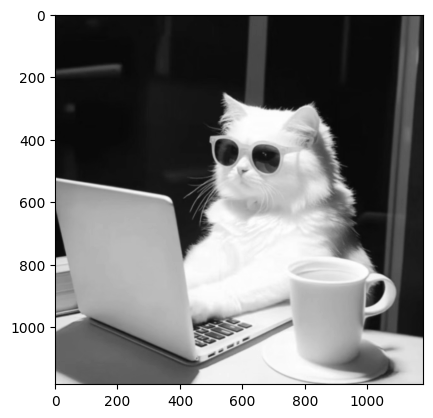

In [51]:
img = img[0:1183,0:1179]#此处可以修改
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')
plt.show()

以上代码得到的图像可以表示为 1100 x 1100 像素数组。接下来，我们减少用于表示图像的像素数量，例如在 100 x 100 阵列上可视化像素值。

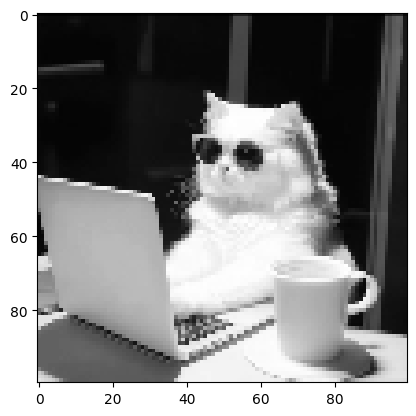

In [52]:
img_gray_small = cv2.resize(img_gray,(100, 100))
plt.imshow(img_gray_small, cmap='gray')
plt.show()

4. 接下来我们检查像素值  


In [53]:
print(img_gray_small)

[[  8   7   6 ...  41  42  13]
 [ 17  16  14 ...  97  95  27]
 [ 15  14  13 ...  97  93  28]
 ...
 [200 183 139 ... 223 222 222]
 [213 209 199 ... 225 224 223]
 [224 218 212 ... 220 220 218]]


### 2.2 彩色图像表示  
我们也可以将以上步骤用于彩色图像上，每个像素可以表示为 3 维向量，最亮的红色像素表示为 (255,0,0)，图像中的纯白色像素表示为 (255,255,255)。接下来，将彩色图像转换为结构化像素值数组。

1. 导入相关库并加载图像

In [54]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread(img_path)

2. 裁剪图像并绘制图像

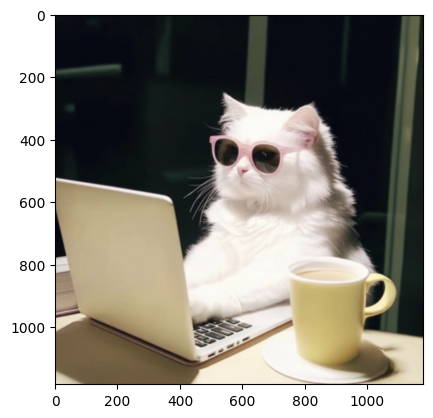

(1183, 1179, 3)


In [55]:
img = img[0:1183,0:1179]#此处可以修改
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()
print(img.shape)

在以上代码中，使用 cv2.cvtcolor 方法对通道进行了重新排序。这是因为使用 cv2 导入图像时，通道的顺序是：蓝色-绿色-红色 (BGR)，但通常，我们习惯于以“红色-绿色-蓝色”的 RGB 通道查看图像。

3.  打印右下角的 3 x 3 像素阵列，并绘制像素值：

[[[225 215 188]
  [225 215 188]
  [224 214 187]]

 [[225 215 188]
  [225 215 188]
  [224 214 187]]

 [[225 215 188]
  [225 215 188]
  [224 214 187]]]


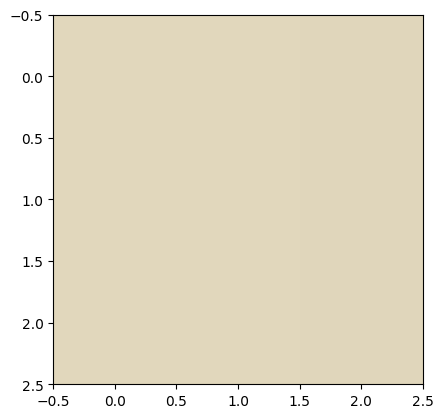

In [56]:
crop = img[-3:,-3:]
print(crop)
plt.imshow(crop)
plt.show()

将图像转换为结构化的数字数组(即将图像读入 Python 内存)使我们能够对图像(表示为数字数组)执行各种数学运算，利用这种数据结构可以执行计算机视觉各种任务，例如分类、检测和分割等。

## 3. 利用神经网络进行图像分析的优势  
在传统计算机视觉中，在将数据输入到模型之前需要利用专业知识为每张图像提取一些特征。接下来，我们根据以下示例图像介绍传统计算机视觉如何获取特征，以了解通过训练神经网络避免手动提取图像特征的优势。

- 直方图特征：对于一些任务，图片中的光照(或者说图像中亮像素和暗像素的比例)十分重要，如夜视应用。下图展示了示例图像的直方图，可以看到图像的暗度较高：

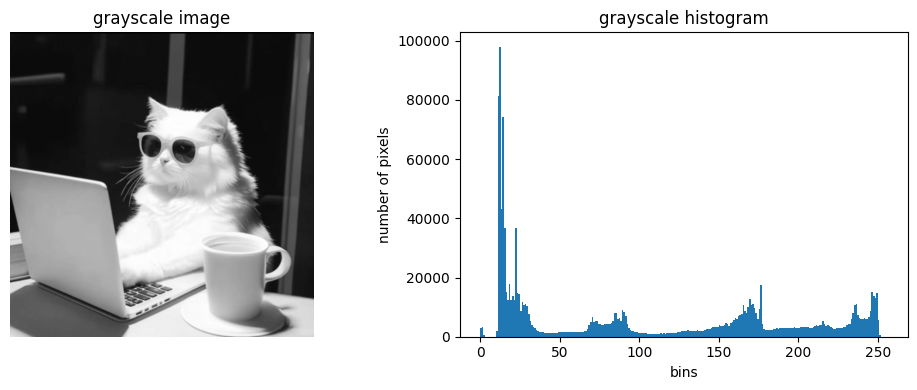

In [57]:
# 2. 转为灰度图
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. 显示灰度图
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('grayscale image')
plt.axis('off')

# 4. 计算并绘制灰度直方图
plt.subplot(1, 2, 2)
plt.hist(img_gray.ravel(), bins=256, range=(0, 256))
plt.title('grayscale histogram')
plt.xlabel('bins')
plt.ylabel('number of pixels')

plt.tight_layout()
plt.show()

- 边和角点特征：对于图像分割等任务，需要获取与每个目标对应的像素集，提取边是一种有效的做法；而在图像匹配等任务中，检测关键点则至关重要，这些关键点是图像中角点的子集。下图表示在示例图像中获得的边和角点：

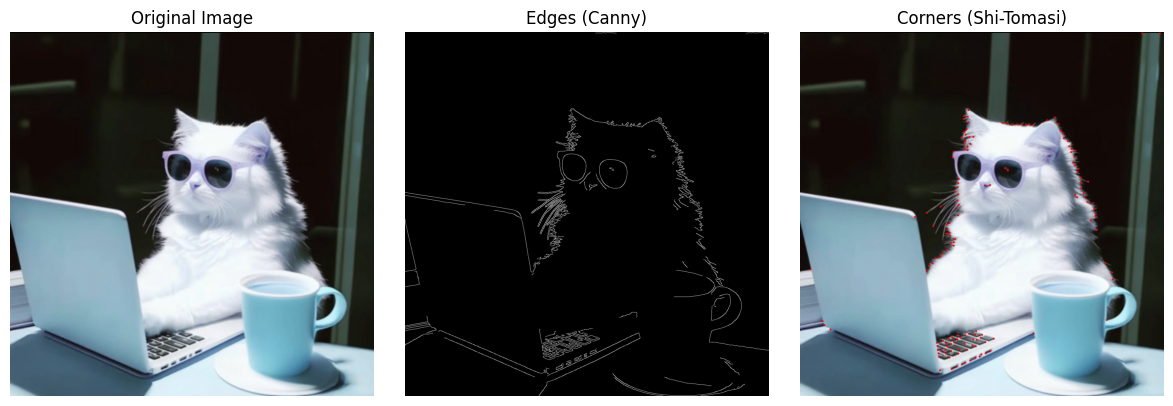

In [60]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. 边检测（Canny）
edges = cv2.Canny(gray, threshold1=80, threshold2=160)

# 3. 角点检测（Shi-Tomasi）
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=150,
    qualityLevel=0.01,
    minDistance=10
)

corner_img = img.copy()
if corners is not None:
    corners = corners.astype(int)
    for x, y in corners.reshape(-1, 2):
        cv2.circle(corner_img, (x, y), 3, (0, 0, 255), -1)

# 4. 可视化
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edges (Canny)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB))
plt.title('Corners (Shi-Tomasi)')
plt.axis('off')

plt.tight_layout()
plt.show()


- 色彩分离特征：在自动驾驶汽车的交通信号灯检测等任务中，通常需要了解交通信号灯上显示的颜色。下图显示了示例图像的红色、绿色和蓝色通道： 

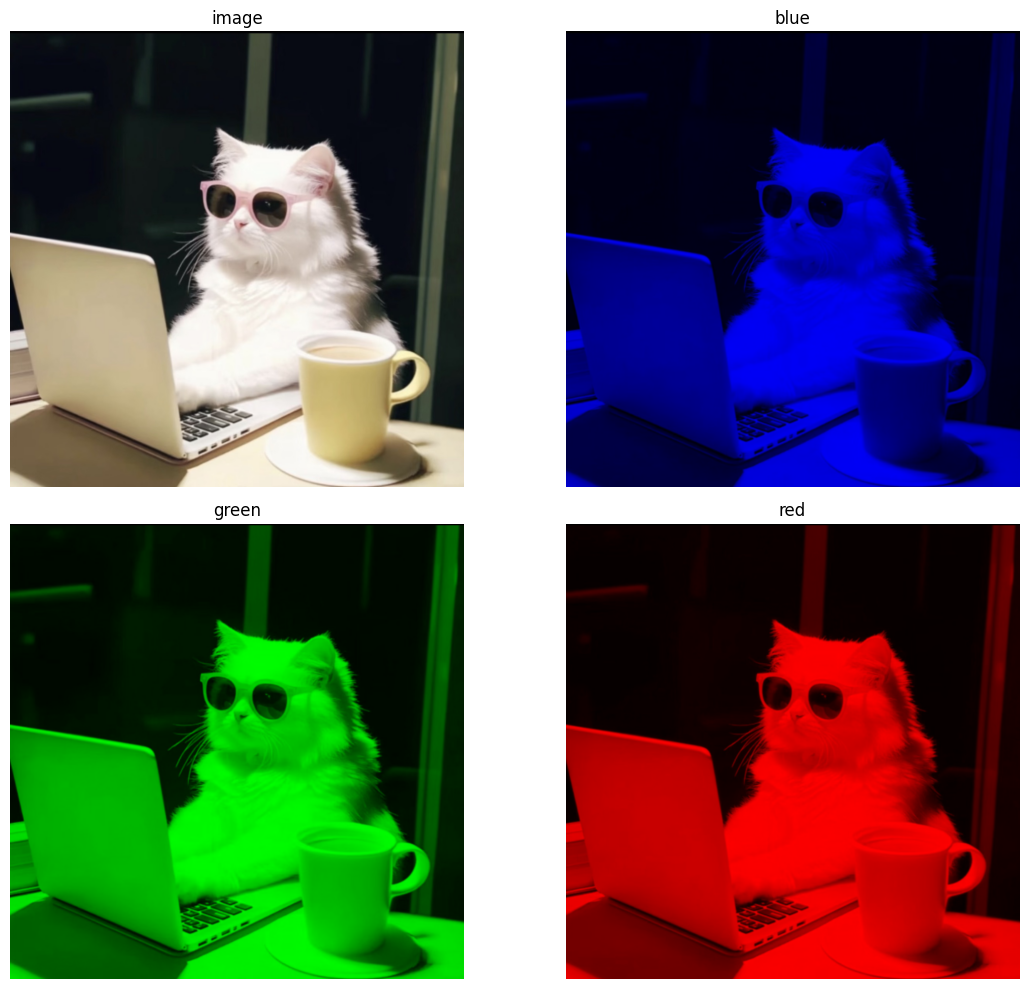

In [61]:
img = cv2.imread(img_path)

if img is None:
    print("无法读取图片，请检查路径！")
else:
    # 2. 将BGR转为RGB（因为cv2默认是BGR，matplotlib是RGB）
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 3. 分离三个通道
    r_channel = img_rgb[:, :, 0]  # 红色通道
    g_channel = img_rgb[:, :, 1]  # 绿色通道
    b_channel = img_rgb[:, :, 2]  # 蓝色通道
    
    # 4. 创建单通道彩色图（用于可视化）
    # 红色通道图：只保留R，G/B置0
    r_img = np.zeros_like(img_rgb)
    r_img[:, :, 0] = r_channel
    
    # 绿色通道图：只保留G，R/B置0
    g_img = np.zeros_like(img_rgb)
    g_img[:, :, 1] = g_channel
    
    # 蓝色通道图：只保留B，R/G置0
    b_img = np.zeros_like(img_rgb)
    b_img[:, :, 2] = b_channel
    
    # 5. 绘制子图（和示例一致：原图 + 蓝 + 绿 + 红）
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 2, 1)
    plt.imshow(img_rgb)
    plt.title("image")
    plt.axis('off')
    
    plt.subplot(2, 2, 2)
    plt.imshow(b_img)
    plt.title("blue")
    plt.axis('off')
    
    plt.subplot(2, 2, 3)
    plt.imshow(g_img)
    plt.title("green")
    plt.axis('off')
    
    plt.subplot(2, 2, 4)
    plt.imshow(r_img)
    plt.title("red")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

- 图像梯度特征：了解颜色在像素级别的变化同样可能非常重要，不同的纹理具有不同的梯度，因此可以将图像梯度用作纹理检测器。事实上，获取梯度是进行边缘检测的先决条件。下图显示了示例图像的整体梯度及其 x 和 y 方向上的分量：

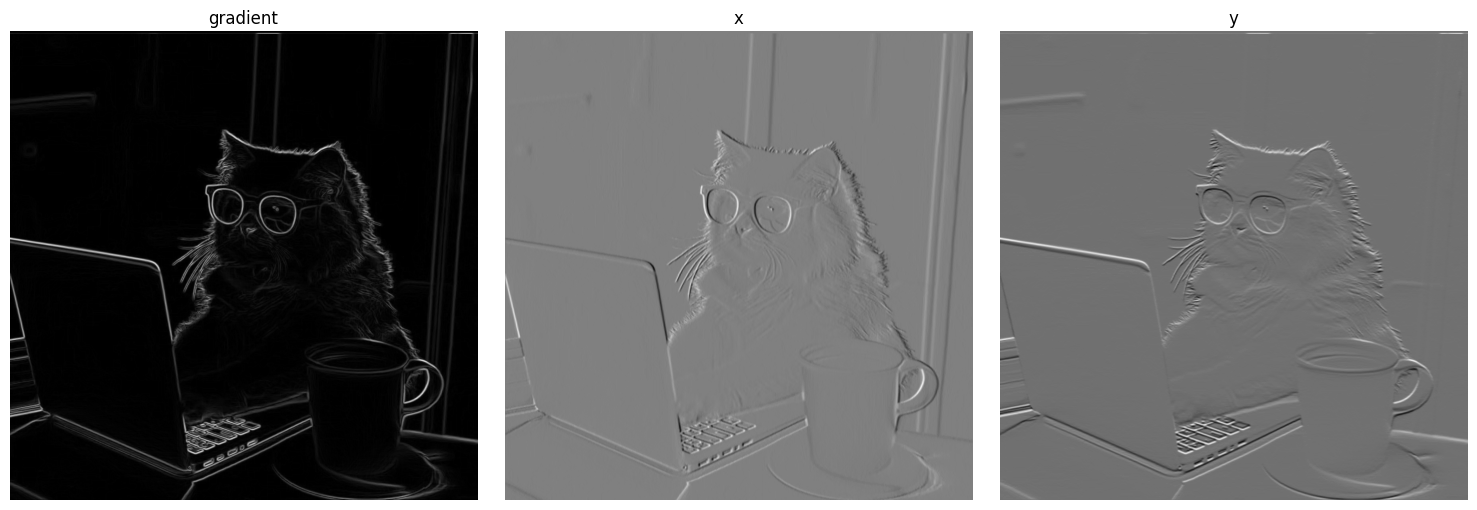

In [62]:
img = cv2.imread(img_path)

if img is None:
    print("无法读取图片，请检查路径！")
else:
    # 转为灰度图
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. 计算x方向和y方向的梯度（使用Sobel算子）
    # x方向梯度（检测垂直边缘）
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    # y方向梯度（检测水平边缘）
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    
    # 3. 计算梯度幅值（整体梯度）
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    # 归一化到0-255以便显示
    gradient_magnitude = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    # 4. 对x、y方向梯度也进行归一化显示
    sobel_x_display = cv2.normalize(sobel_x, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    sobel_y_display = cv2.normalize(sobel_y, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    # 5. 绘制子图（整体梯度 + x分量 + y分量）
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(gradient_magnitude, cmap='gray')
    plt.title("gradient")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(sobel_x_display, cmap='gray')
    plt.title("x")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(sobel_y_display, cmap='gray')
    plt.title("y")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

以上特征只是诸多图像特征中的一小部分，构建这些特征需要了解图像和信号分析方面的大量知识，并且应该充分了解哪些特征最适合解决问题。即使满足这两个约束条件，也不能保证能够找到正确的输入特征组合，即使找到这样的特征，也不能保证其在新的应用场景中能够起作用。  
基于神经网络的模型不仅能提取正确的特征，还能学习如何进行最佳组合完成目标任务，解决了传统特征提取的缺点，也就是说，神经网络既可以作为特征提取器，也可以作为分类器。 

综上，利用神经网络进行图像分析具有以下几个优势：  
- 自动特征学习：传统的图像分析方法需要手动提取特征，而神经网络可以自动学习图像中的特征表示。通过多层神经网络的堆叠和训练，网络可以学习到不同层次的特征抽象，从低层次的边缘和纹理到高层次的对象和语义概念。这种自动特征学习使得神经网络在复杂的图像分析任务中表现出色。  
- 非线性建模能力：神经网络是一种非线性模型，可以更好地建模和捕捉图像中的非线性关系。由于图像具有丰富的结构、纹理和形态信息，线性模型无法充分表示这些复杂特征。神经网络通过激活函数和多层连接来引入非线性变换，从而更好地适应各种图像分析任务。  
- 鲁棒性和泛化能力：神经网络在大规模数据集上进行训练，并具有较强的鲁棒性和泛化能力。这意味着网络能够处理具有不同视角、光照条件、噪声等变化的图像，并且在未见过的数据上也能有良好的表现。通过合理设计和训练，神经网络可以对图像中的变化和干扰具有一定的容忍度。  
- 端到端学习：神经网络可以实现端到端学习，从原始图像输入到最终的输出结果，无需手工设计复杂的流程和特征转换。这简化了图像分析系统的开发和部署过程，同时减少了人工错误和信息损失。通过端到端学习，神经网络可以直接从数据中学习到有效的表示和决策规则。  
- 可扩展性和灵活性：神经网络可以通过增加网络层数、调整神经元数量以及引入不同的模块和结构来提高模型的能力。这使得神经网络具有很强的可扩展性和灵活性，在各类图像分析任务中可以根据需求进行调整和优化。

## 小结  
利用神经网络进行图像分析能够自动学习特征、处理非线性关系、具有鲁棒性和泛化能力，并且支持端到端学习和可扩展性，这使其成为当今计算机视觉领域的主要技术手段之一。本节介绍了计算机视觉的基本概念以及图像在计算机中的表示方法，为计算机视觉的高级任务奠定了基础。